# ECG5000 Data Exploration

这个 notebook 先做轻量的数据观察：读取 ECG5000 的 train/test 文件，确认数据形状、类别分布、数值范围，并画一些 ECG 波形看看整体长什么样。这里暂时不做模型训练。

## 1. Imports and Paths

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "dataset"

TRAIN_PATH = DATA_DIR / "ECG5000_TRAIN.txt"
TEST_PATH = DATA_DIR / "ECG5000_TEST.txt"

TRAIN_PATH, TEST_PATH

(WindowsPath('c:/Users/ZifengLiang/Desktop/cloudMLEProject/dataset/ECG5000_TRAIN.txt'),
 WindowsPath('c:/Users/ZifengLiang/Desktop/cloudMLEProject/dataset/ECG5000_TEST.txt'))

## 2. Load Data

`.txt` 文件第一列是标签，后面 140 列是单条 ECG 时间序列。

In [3]:
def load_ecg5000_txt(path: Path):
    data = np.loadtxt(path)
    y = data[:, 0].astype(int)
    X = data[:, 1:]
    return X, y


X_train, y_train = load_ecg5000_txt(TRAIN_PATH)
X_test, y_test = load_ecg5000_txt(TEST_PATH)

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

print("Train features:", X_train.shape)
print("Train labels:", y_train.shape)
print("Test features:", X_test.shape)
print("Test labels:", y_test.shape)
print("All features:", X_all.shape)
print("All labels:", y_all.shape)

Train features: (500, 140)
Train labels: (500,)
Test features: (4500, 140)
Test labels: (4500,)
All features: (5000, 140)
All labels: (5000,)


## 3. Basic Dataset Summary

In [4]:
def split_summary(name, X, y):
    return {
        "split": name,
        "samples": len(y),
        "series_length": X.shape[1],
        "classes": sorted(np.unique(y).tolist()),
        "missing_values": int(np.isnan(X).sum()),
        "min": float(np.min(X)),
        "max": float(np.max(X)),
        "mean": float(np.mean(X)),
        "std": float(np.std(X)),
    }


summary_df = pd.DataFrame([
    split_summary("train", X_train, y_train),
    split_summary("test", X_test, y_test),
    split_summary("all", X_all, y_all),
])

summary_df

,split,samples,series_length,classes,missing_values,min,max,mean,std
0,train,500,140,"[1, 2, 3, 4, 5]",0,-5.797645,4.058127,7.354923e-11,0.996422
1,test,4500,140,"[1, 2, 3, 4, 5]",0,-7.090374,7.402103,-1.064666e-11,0.996422
2,all,5000,140,"[1, 2, 3, 4, 5]",0,-7.090374,7.402103,-2.227071e-12,0.996422


## 4. Class Distribution

ECG5000 的类别分布很不均衡，后续如果做模型，不能只看 accuracy。

In [5]:
def class_distribution(y, split_name):
    counts = Counter(y.tolist())
    total = len(y)
    rows = []
    for label in sorted(counts):
        rows.append({
            "split": split_name,
            "class": label,
            "count": counts[label],
            "percentage": counts[label] / total * 100,
        })
    return rows


class_df = pd.DataFrame(
    class_distribution(y_train, "train")
    + class_distribution(y_test, "test")
    + class_distribution(y_all, "all")
)

class_df

,split,class,count,percentage
0,train,1,292,58.400000
1,train,2,177,35.400000
2,train,3,10,2.000000
3,train,4,19,3.800000
4,train,5,2,0.400000
5,test,1,2627,58.377778
6,test,2,1590,35.333333
7,test,3,86,1.911111
8,test,4,175,3.888889
9,test,5,22,0.488889


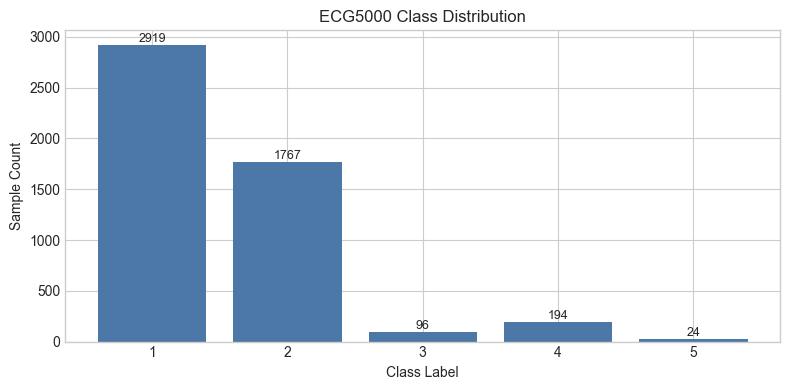

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

all_counts = class_df[class_df["split"] == "all"].set_index("class")["count"]
ax.bar(all_counts.index.astype(str), all_counts.values, color="#4C78A8")
ax.set_title("ECG5000 Class Distribution")
ax.set_xlabel("Class Label")
ax.set_ylabel("Sample Count")

for idx, value in enumerate(all_counts.values):
    ax.text(idx, value, str(value), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Plot Example ECG Signals

每个类别抽几条样本看一下波形。这里先画全部数据里的样本，不区分 train/test。

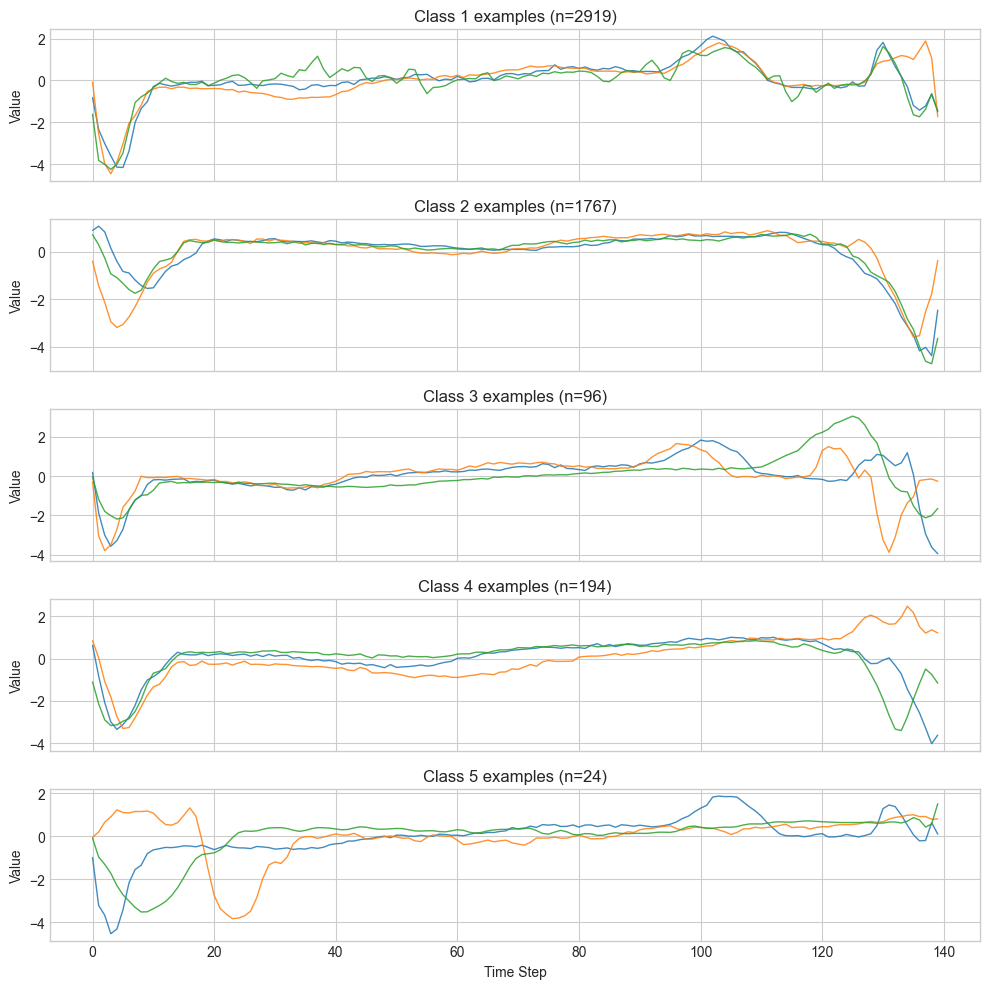

In [7]:
def plot_samples_by_class(X, y, samples_per_class=3, random_state=42):
    rng = np.random.default_rng(random_state)
    classes = sorted(np.unique(y))
    time_axis = np.arange(X.shape[1])

    fig, axes = plt.subplots(len(classes), 1, figsize=(10, 10), sharex=True)

    for ax, label in zip(axes, classes):
        indices = np.where(y == label)[0]
        chosen = rng.choice(indices, size=min(samples_per_class, len(indices)), replace=False)

        for idx in chosen:
            ax.plot(time_axis, X[idx], linewidth=1, alpha=0.85)

        ax.set_title(f"Class {label} examples (n={len(indices)})")
        ax.set_ylabel("Value")

    axes[-1].set_xlabel("Time Step")
    plt.tight_layout()
    plt.show()


plot_samples_by_class(X_all, y_all)

## 6. Mean Signal by Class

画每个类别的平均波形，快速看类别之间有没有明显形态差异。

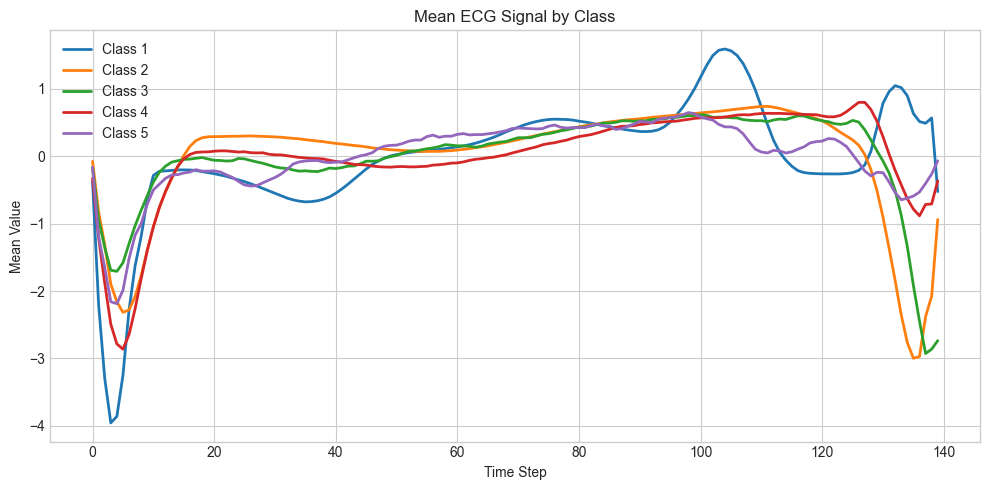

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
time_axis = np.arange(X_all.shape[1])

for label in sorted(np.unique(y_all)):
    class_mean = X_all[y_all == label].mean(axis=0)
    ax.plot(time_axis, class_mean, linewidth=2, label=f"Class {label}")

ax.set_title("Mean ECG Signal by Class")
ax.set_xlabel("Time Step")
ax.set_ylabel("Mean Value")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Simple Observations

- 每条样本长度固定为 140，适合直接送入 MLP、1D-CNN、LSTM 等模型。
- 数据已经接近标准化，整体均值接近 0，标准差接近 1。
- 类别非常不均衡，尤其是 class 5 样本极少。
- 后续做 MLflow 时，建议记录 per-class precision/recall/F1 和 confusion matrix，而不是只记录 accuracy。
- 这个项目的优先级是练习数据流、实验追踪、模型制品和 AWS 部署流程，不需要过度追求模型分数。